In [10]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

%matplotlib inline

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

data = torch.load('../data/HopperPhysics/training.pt', map_location='cpu', weights_only=False)
if isinstance(data, np.ndarray):
    data = torch.tensor(data, dtype=torch.float32)

print(f'Shape: {data.shape}')  # (10000, 200, 14)

# 14 каналов оригинального датасета авторов
CHANNEL_NAMES = [
    'rootz (высота)',        # 0
    'rooty (угол туловища)', # 1
    'thigh (угол бедра)',    # 2
    'leg (угол голени)',     # 3
    'foot (угол ступни)',    # 4
    'vx (гориз. скорость)',  # 5
    'vz (верт. скорость)',   # 6
    'vrooty',                # 7
    'vthigh',                # 8
    'vleg',                  # 9
    'vfoot',                 # 10
    'touch_foot',            # 11
    'touch_toe',             # 12
    'extra',                 # 13
]

Shape: torch.Size([10000, 200, 14])


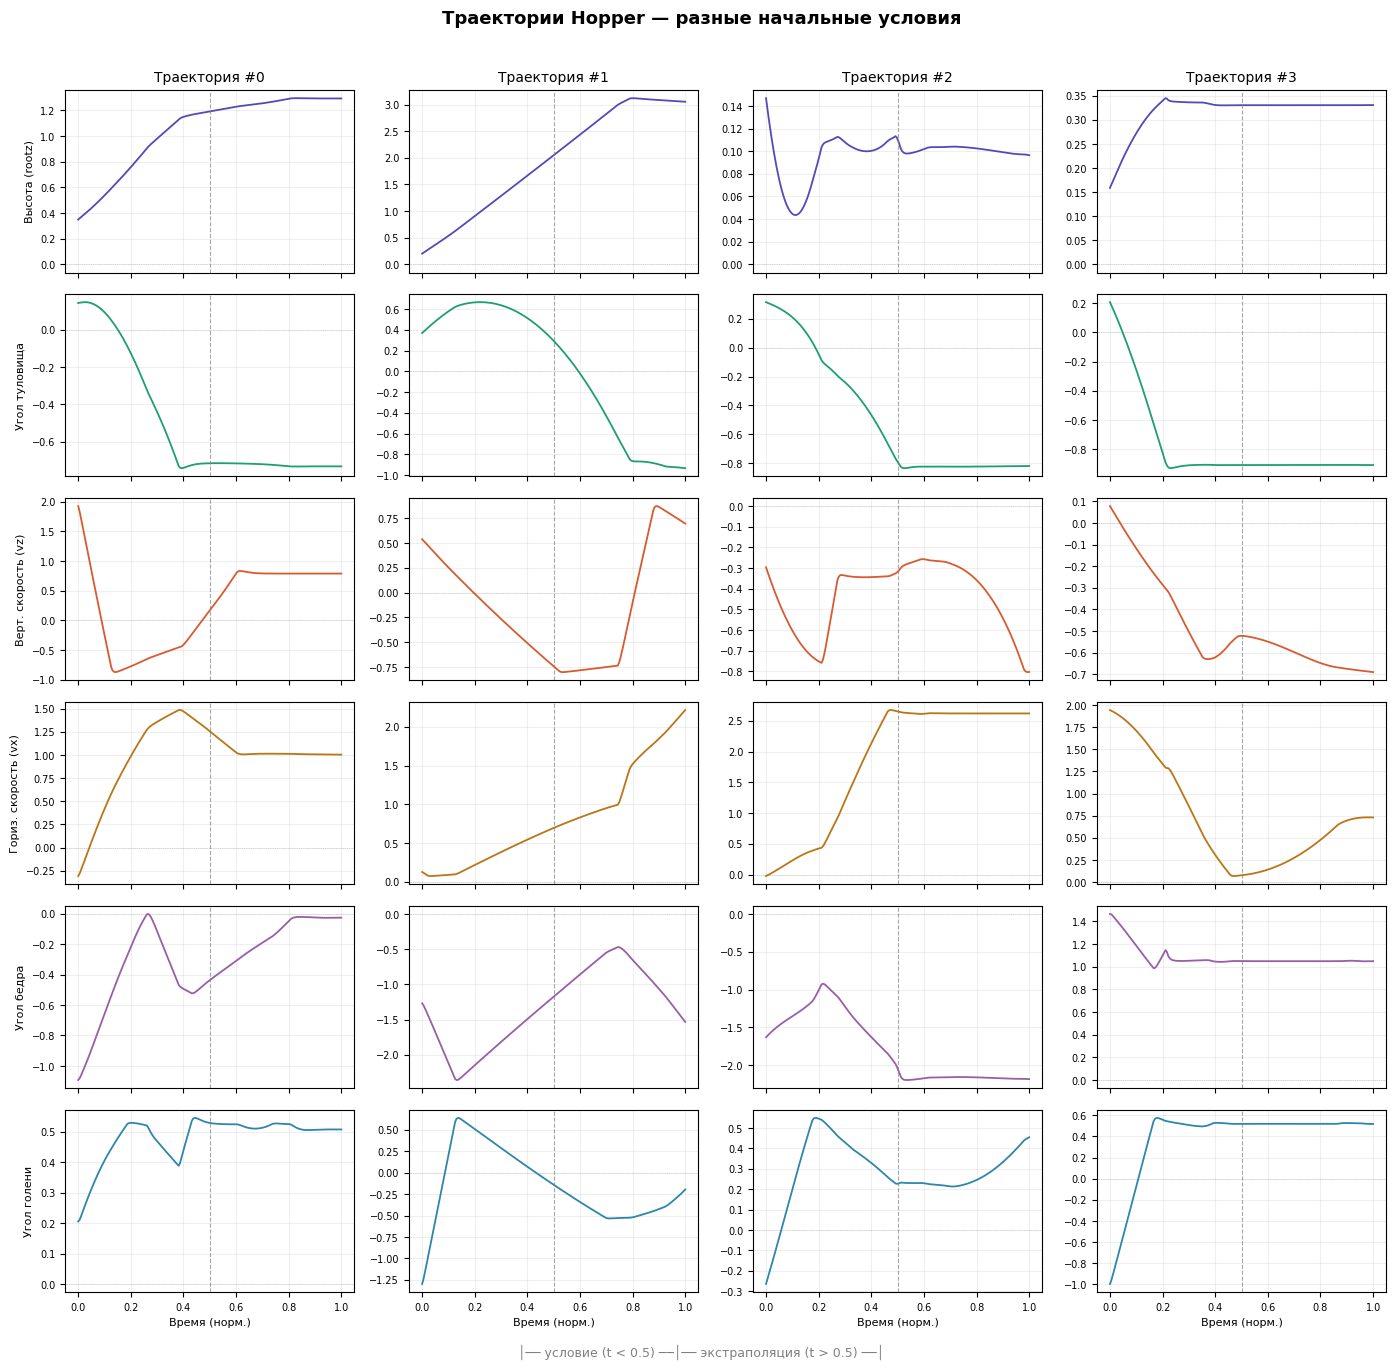

Сохранено: hopper_trajectories.png


In [12]:
# ── параметры ──────────────────────────────────────────────────────────────
TRAJ_INDICES = [0, 1, 2, 3]   # какие траектории смотреть

# какие каналы показывать
CHANNELS_TO_PLOT = {
    'Высота (rootz)':       0,
    'Угол туловища':        1,
    'Верт. скорость (vz)':  6,
    'Гориз. скорость (vx)': 5,
    'Угол бедра':           2,
    'Угол голени':          3,
}

COLORS = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#985EA6', '#2E86AB']

n_traj = len(TRAJ_INDICES)
n_ch   = len(CHANNELS_TO_PLOT)
T      = data.shape[1]
t      = np.linspace(0, 1, T)

fig, axes = plt.subplots(n_ch, n_traj,
                         figsize=(n_traj * 3.5, n_ch * 2.2),
                         sharex=True)
fig.suptitle('Траектории Hopper — разные начальные условия',
             fontsize=13, fontweight='bold', y=1.01)

for col, traj_idx in enumerate(TRAJ_INDICES):
    traj = data[traj_idx].numpy()   # (200, 14)
    axes[0][col].set_title(f'Траектория #{traj_idx}', fontsize=10)

    for row, (ch_name, ch_idx) in enumerate(CHANNELS_TO_PLOT.items()):
        ax = axes[row][col]
        ax.plot(t, traj[:, ch_idx], color=COLORS[row], linewidth=1.3)

        # вертикальная линия — граница условие/экстраполяция
        ax.axvline(0.5, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.7)
        ax.axhline(0, color='gray', linewidth=0.5,
                   linestyle=':', alpha=0.5)
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=7)

        if col == 0:
            ax.set_ylabel(ch_name, fontsize=8)

    axes[-1][col].set_xlabel('Время (норм.)', fontsize=8)

# подпись разделителя
fig.text(0.5, -0.01,
         '│── условие (t < 0.5) ──│── экстраполяция (t > 0.5) ──│',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('hopper_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: hopper_trajectories.png')

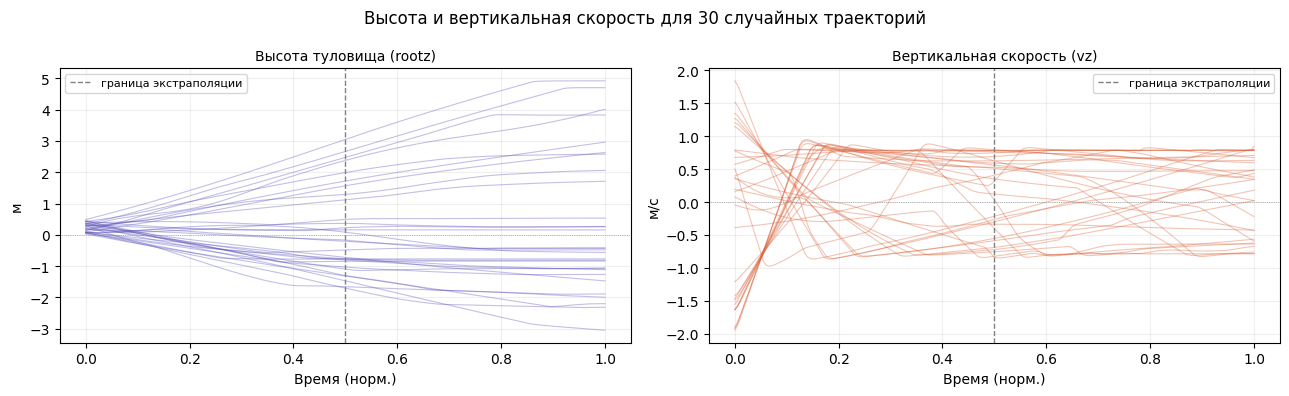

Сохранено: hopper_many_trajectories.png


In [13]:
# ── сравнение высоты для многих траекторий ────────────────────────────────
# хорошо видно насколько разные начальные условия

N_SHOW = 30
np.random.seed(42)
indices = np.random.choice(len(data), size=N_SHOW, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Высота и вертикальная скорость для {N_SHOW} случайных траекторий',
             fontsize=12)

for idx in indices:
    traj = data[idx].numpy()
    alpha = 0.35
    axes[0].plot(t, traj[:, 0], color='#534AB7', alpha=alpha, linewidth=0.8)
    axes[1].plot(t, traj[:, 6], color='#D85A30', alpha=alpha, linewidth=0.8)

for ax, title, ylabel in zip(
    axes,
    ['Высота туловища (rootz)', 'Вертикальная скорость (vz)'],
    ['м', 'м/с']
):
    ax.axvline(0.5, color='gray', linewidth=1.0, linestyle='--', label='граница экстраполяции')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.set_xlabel('Время (норм.)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('hopper_many_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: hopper_many_trajectories.png')

In [14]:
# ── статистика по датасету ────────────────────────────────────────────────
print(f'Датасет: {data.shape[0]} траекторий, {data.shape[1]} точек, {data.shape[2]} каналов')
print(f'\n{"Канал":<25} {"min":>8} {"max":>8} {"mean":>8} {"std":>8}')
print('-' * 55)
for ch, name in enumerate(CHANNEL_NAMES):
    vals = data[:, :, ch].numpy()
    print(f'{name:<25} {vals.min():>8.3f} {vals.max():>8.3f} '
          f'{vals.mean():>8.3f} {vals.std():>8.3f}')

Датасет: 10000 траекторий, 200 точек, 14 каналов

Канал                          min      max     mean      std
-------------------------------------------------------
rootz (высота)              -6.154    6.702    0.248    1.320
rooty (угол туловища)       -0.983    2.773   -0.244    0.670
thigh (угол бедра)         -11.755   12.485    0.331    2.731
leg (угол голени)           -2.000    2.000    0.046    0.416
foot (угол ступни)          -2.926    1.998   -1.140    1.022
vx (гориз. скорость)        -1.999    2.909    1.280    0.973
vz (верт. скорость)         -2.000    2.000    0.063    0.606
vrooty                      -8.783    9.737    0.009    2.291
vthigh                      -9.323    7.613   -0.991    2.012
vleg                       -47.243   66.820    0.331    6.506
vfoot                      -43.079   93.305    0.046    5.277
touch_foot                 -59.637   30.623   -1.137    6.508
touch_toe                  -54.284   72.312    1.304    7.075
extra                     

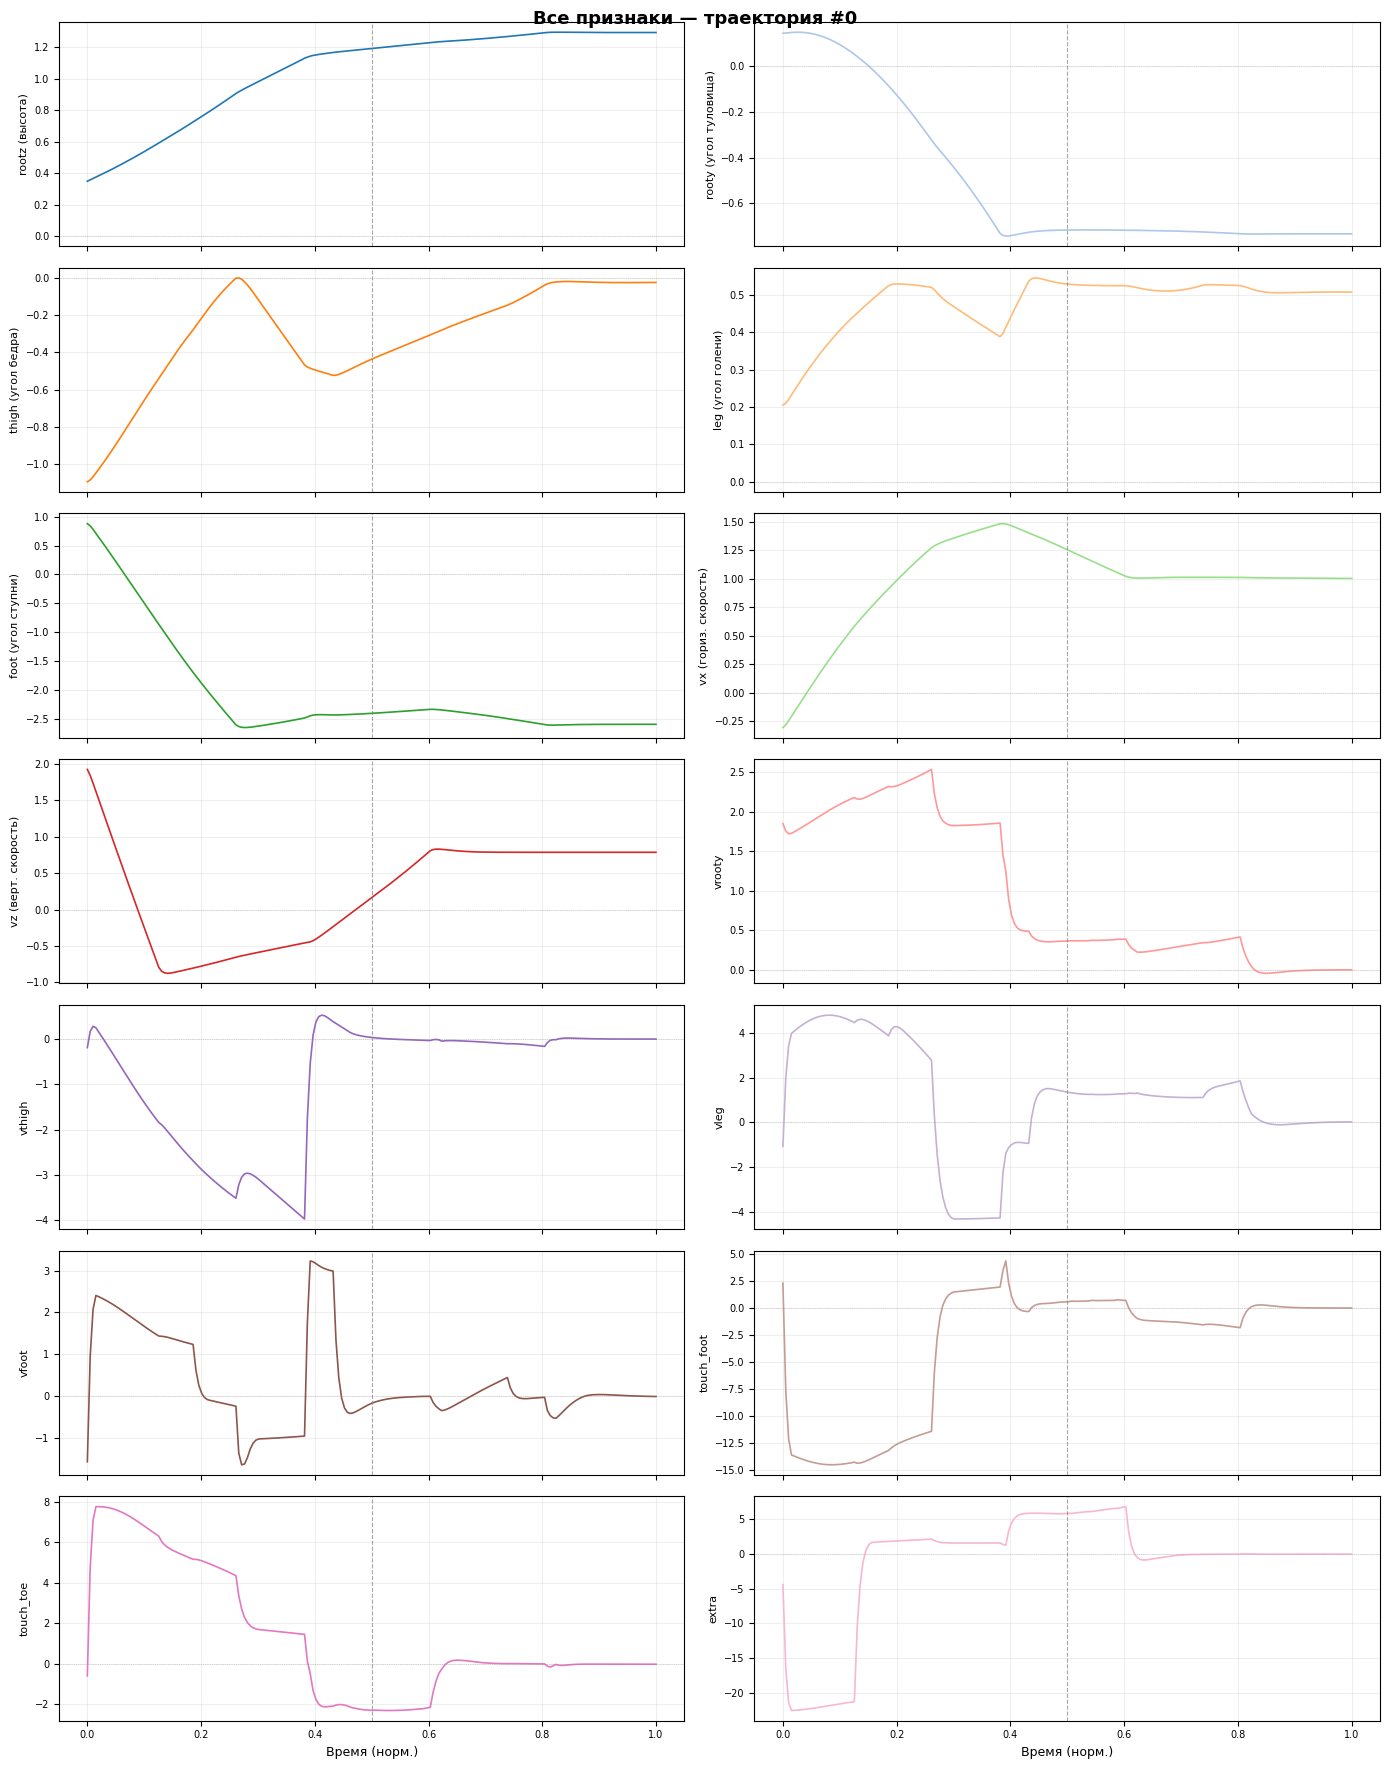

Сохранено: hopper_all_features_traj0.png


In [15]:
# ── все 14 признаков для траектории 0 ─────────────────────────────────────
TRAJ_IDX = 0
traj = data[TRAJ_IDX].numpy()  # (200, 14)
T = data.shape[1]
t = np.linspace(0, 1, T)

COLORS = plt.cm.tab20.colors

fig, axes = plt.subplots(7, 2, figsize=(14, 18), sharex=True)
fig.suptitle(f'Все признаки — траектория #{TRAJ_IDX}', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ch, (ax, name) in enumerate(zip(axes, CHANNEL_NAMES)):
    ax.plot(t, traj[:, ch], color=COLORS[ch], linewidth=1.2)
    ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
    ax.set_ylabel(name, fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=7)

for ax in axes[-2:]:
    ax.set_xlabel('Время (норм.)', fontsize=9)

plt.tight_layout()
plt.savefig(f'hopper_all_features_traj{TRAJ_IDX}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Сохранено: hopper_all_features_traj{TRAJ_IDX}.png')

In [16]:
import torch
import numpy as np

data = torch.load('./data/HopperPhysics/training.pt',
                  map_location='cpu', weights_only=False)

print(f'{"Канал":<5} {"min":>10} {"max":>10} {"mean":>10} {"std":>10}')
print('-' * 50)
for ch in range(14):
    vals = data[:, :, ch].flatten()
    print(f'{ch:<5} {vals.min():>10.3f} {vals.max():>10.3f} {vals.mean():>10.3f} {vals.std():>10.3f}')

FileNotFoundError: [Errno 2] No such file or directory: './data/HopperPhysics/training.pt'

In [ ]:
from dm_control import suite
import numpy as np

env = suite.load('hopper', 'hop')
env.reset()
physics = env.physics

print('=== qpos ===')
print('shape:', physics.data.qpos.shape)
print('values:', physics.data.qpos)

print('\n=== qvel ===')
print('shape:', physics.data.qvel.shape)
print('values:', physics.data.qvel)

print('\n=== sensordata ===')
print('shape:', physics.data.sensordata.shape)
print('values:', physics.data.sensordata)

# имена сенсоров
print('\n=== sensor names ===')
model = physics.model
for i in range(model.nsensor):
    name = model.id2name(i, 'sensor')
    print(f'  sensor {i}: {name}')

# имена суставов
print('\n=== joint names ===')
for i in range(model.njnt):
    name = model.id2name(i, 'joint')
    print(f'  joint {i}: {name}')

=== qpos ===
shape: (7,)
values: [ 0.          0.         -1.75420505 -0.22418214 -2.82052146  1.1507959
 -0.18643551]

=== qvel ===
shape: (7,)
values: [0. 0. 0. 0. 0. 0. 0.]

=== sensordata ===
shape: (5,)
values: [0. 0. 0. 0. 0.]

=== sensor names ===
  sensor 0: torso_subtreelinvel
  sensor 1: touch_toe
  sensor 2: touch_heel

=== joint names ===
  joint 0: rootx
  joint 1: rootz
  joint 2: rooty
  joint 3: waist
  joint 4: hip
  joint 5: knee
  joint 6: ankle


In [ ]:
# смотрим как именно авторы собирали наблюдения
# скорее всего они брали конкретные поля из physics

from dm_control import suite
import numpy as np

env = suite.load('hopper', 'hop')
time_step = env.reset()
physics = env.physics

# что возвращает observation напрямую
obs = time_step.observation
print('=== observation keys ===')
for k, v in obs.items():
    print(f'  {k}: shape={v.shape}, values={v}')

print('\n=== subtreelinvel ===')
print(physics.data.sensordata[0:3])  # torso_subtreelinvel это 3D вектор?

print('\n=== touch sensors ===')
print('touch_toe:', physics.data.sensordata[3])
print('touch_heel:', physics.data.sensordata[4])

print('\ntotal obs size:', sum(v.size for v in obs.values()))

=== observation keys ===
  position: shape=(6,), values=[ 0.          1.83445835  0.47222064 -0.51972498  0.27592743  0.5464784 ]
  velocity: shape=(7,), values=[0. 0. 0. 0. 0. 0. 0.]
  touch: shape=(2,), values=[0. 0.]

=== subtreelinvel ===
[0. 0. 0.]

=== touch sensors ===
touch_toe: 0.0
touch_heel: 0.0

total obs size: 15


In [ ]:
from dm_control import suite
import numpy as np

env = suite.load('hopper', 'hop')
physics = env.physics

# смотрим что именно в position
print('=== position (6 элементов) ===')
# position это qpos[1:] — без rootx
print('qpos[1:]:', physics.data.qpos[1:])
print()

# делаем один шаг и собираем obs как авторы
time_step = env.reset()
physics.data.qpos[:] = np.array([0, 0.5, -0.3, -0.5, 0.3, 1.0, 0.2])
physics.data.qvel[:] = np.array([1.0, -0.5, 0.3, -1.0, 0.5, -0.3, 0.8])
physics.forward()

obs = env.task.get_observation(physics)
print('=== после установки состояния ===')
for k, v in obs.items():
    print(f'  {k}: {v}')

# пробуем собрать 14-мерный вектор
candidate = np.concatenate([
    obs['position'],   # 6
    obs['velocity'],   # 7
    obs['touch'],      # 2
])
print('\ncandidate shape:', candidate.shape)  # должно быть 15

candidate14 = np.concatenate([
    obs['position'],   # 6
    obs['velocity'],   # 7
    obs['touch'][:1],  # 1
])
print('candidate14 shape:', candidate14.shape)

=== position (6 элементов) ===
qpos[1:]: [0. 0. 0. 0. 0. 0.]

=== после установки состояния ===
  position: [ 0.5 -0.3 -0.5  0.3  1.   0.2]
  velocity: [ 1.  -0.5  0.3 -1.   0.5 -0.3  0.8]
  touch: [0. 0.]

candidate shape: (15,)
candidate14 shape: (14,)
